In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.sparse.linalg import eigsh
from tqdm.notebook import tqdm

from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d

import random
from sympy import Matrix
import cvxpy as cp

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],   # default LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 15, 
})

In [2]:
# Parameters 

L = 6 # Length of the chain / Number of sites
M = 2*L # Number of modes
N = 3**M # Total number of pulses
I = L-1 # Number of hopping terms (per spin)
R = 2*I # Number of rows / total hopping terms
ratio = 6 # Column to row ratio
K = ratio*R # Number of pulses (columns) to be considered

In [3]:
# FUNCTIONS
#------------------------------------------------------------------------------------------------
# Function for calculating row labels

def one_dim_chain_row_labels(I,L):
    rows  = np.zeros(shape = (I,L) , dtype=np.float64)
    
    for i in range(I):
        for j in range(L):
            if rows[i][i+j] == 0 and rows[i][i+j+1] == 0:
                rows[i][i+j] = 1
                rows[i][i+j+1] = 2
            else:
                break
    return rows

rows = one_dim_chain_row_labels(I,L)

def spinful_rows(rows):
    
    zero_vec = np.zeros(shape= L, dtype=np.float64)
    
    rows_up = np.array([np.concatenate([rows[j],zero_vec]) for j in range(len(rows))])
    rows_down = np.array([np.concatenate([zero_vec,rows[j]]) for j in range(len(rows))])
    
    spinful_rows = np.concatenate([rows_up,rows_down])
    return spinful_rows

spinful_rows = spinful_rows(rows)
#------------------------------------------------------------------------------------------------
# Function which takes a number between 0 and N-1 and converts it to a base 3 array

def tritarray(x,M):
    tritarray = np.zeros(shape = M)
    for j in range(M):
        r = x % 3
        x = x // 3 
        tritarray[-(j+1)] = r
    return tritarray

#------------------------------------------------------------------------------------------------
# Function for selecting K random pulses on M modes

def random_pulses(M,K):
    
    N = 3**M
    
    sample = random.sample(range(N),K) 
    pulses = np.zeros(shape = (K,M)) # K pulses of length M
    
    for j in range(K):
        pulses[j] = tritarray(sample[j],M)
        
    return pulses

#------------------------------------------------------------------------------------------------

# Check if F is feasible
def check_feasible(F):

    x = cp.Variable(F.shape[1])
    objective = cp.Minimize(cp.sum(x))
    constraints = [F @ x == 0, x >= 1]

    # Define and solve the problem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver = cp.MOSEK)

    # # Print solution
    # print("Optimal value:", problem.value)
    # print("Optimal x:", x.value)
    
    LP_has_solution = 0
    F_has_full_rank = 0
    
    if type(x.value) == np.ndarray:
        LP_has_solution = 1
    if F.shape[0]- np.linalg.matrix_rank(F)==0:
        F_has_full_rank = 1
    feasible = LP_has_solution * F_has_full_rank
    
    return bool(feasible)
#------------------------------------------------------------------------------------------------
# Function for finding the constraint matrix with random pulses (should work on other geometries)

def constraint_matrix_random_pulses(L,K,spinful_rows):

    I = int((L-1)) 
    R = 2*I
    M = 2*L
    pulses = random_pulses(M,K)
    F = np.zeros(shape = (R,K), dtype=np.complex128)
    w = np.exp(1j*2*np.pi/3)

    for i in range(R):
        for j in range(K):
            power = spinful_rows[i]@pulses[j]
            F[i][j] = w**power

    return F,pulses
#------------------------------------------------------------------------------------------------
# Function for finding the constraint matrix with given pulses (should work on other geometries)

def constraint_matrix_given_pulses(L,K,spinful_rows,pulses):

    I = int((L-1)) 
    R = 2*I
    F = np.zeros(shape = (R,K), dtype=np.complex128)
    w = np.exp(1j*2*np.pi/3)

    for i in range(R):
        for j in range(K):
            power = spinful_rows[i]@pulses[j]
            F[i][j] = w**power

    return F

#------------------------------------------------------------------------------------------------
# Random target Hamiltonian coefficients

def random_hamiltonian_coef(R, magnitude=1):
    # uniform angle
    theta = 2 * np.pi * np.random.rand(R)
    # radius distributed as sqrt of uniform to get uniform area measure
    r = magnitude * np.sqrt(np.random.rand(R))
    return r * np.exp(1j * theta)

#------------------------------------------------------------------------------------------------
# Hamiltonian Engineering
def hamiltonian_engineering(L,K,spinful_rows,pulses,beta):

    F = constraint_matrix_given_pulses(L,K,spinful_rows,pulses)
    
    # print(check_feasible(F))

    x = cp.Variable(K)
    objective = cp.Minimize(cp.sum(x))
    constraints = [F @ x == beta, x>=0]

    # Define and solve the problem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver = cp.MOSEK)

    # # Print solution
    # print("Optimal value:", problem.value)
    # print("Optimal x:", x.value)
    
    return problem.value, x.value

#------------------------------------------------------------------------------------------------
# Function to find the support sets of a pulse

def support_set_finder(pulse, L = L):
    support_up = []
    support_down = []
    for j in range(len(pulse)//2):
        if pulse[j] != 0:
            support_up.append(j%L) 
    for j in range(L,len(pulse)//2+L):
        if pulse[j] != 0:
            support_down.append(j%L) 
    support_up = np.array(support_up)
    support_down = np.array(support_down)
    return support_up, support_down

#------------------------------------------------------------------------------------------------
# Pulse Hamiltonian for a single pulse

def pulse_hamiltonian(pulse, L = L, pulse_strength = 2*np.pi/3):
    
    support_up , support_down = support_set_finder(pulse,L)
    pulse_up_list = [[(-1)**(pulse[j]-1)*pulse_strength,j] for j in support_up]
    pulse_down_list = [[(-1)**(pulse[j+L]-1)*pulse_strength,j] for j in support_down]
    
    static_pulse = [
    ["n|", pulse_up_list],  
    ["|n", pulse_down_list],
    ]
    
    dynamic = []
    
    H_pulse = hamiltonian(static_pulse, dynamic, basis=basis, dtype=np.complex128,check_herm=False,check_symm=False,check_pcon=False)
    
    return H_pulse

#------------------------------------------------------------------------------------------------
# Pulse Hamiltonian for the conjugate pulse

def conj_pulse_hamiltonian(pulse, L = L, pulse_strength = 2*np.pi/3):
    
    support_up , support_down = support_set_finder(pulse)
    pulse_up_list = [[(-1)**(pulse[j]-1)*-pulse_strength,j] for j in support_up]
    pulse_down_list = [[(-1)**(pulse[j+L]-1)*-pulse_strength,j] for j in support_down]
    
    static_pulse = [
    ["n|", pulse_up_list],  
    ["|n", pulse_down_list],
    ]
    
    dynamic = []
    
    H_pulse_conj = hamiltonian(static_pulse, dynamic, basis=basis, dtype=np.complex128,check_herm=False,check_symm=False,check_pcon=False)
    
    return H_pulse_conj

#----------------------------------------------------------------------------------------------
# Quench operator with  first order trotter formula


def quench_operator(t,pulses,times,  H_S, pulse_strength = 2*np.pi/3,trotter = 1,):
    U = np.identity(np.shape(H_S)[0],dtype=np.complex128)
    HS = H_S.toarray()
    for k in range(K):
        H_pulse = pulse_hamiltonian(pulses[k],L,pulse_strength).toarray()

        P = expm(-1j*H_pulse)
        
        U = expm(-1j*(t/trotter)*times[k]*P.T.conj()@HS@P)@U
    
    U = np.linalg.matrix_power(U,trotter)
    
    return U



#----------------------------------------------------------------------------------------------
# Quench operator with  second order trotter formula

def quench_operator2(t,pulses,times, H_S, pulse_strength = 2*np.pi/3,trotter = 1):
    HS = H_S.toarray()
    
    U = np.identity(np.shape(HS)[0],dtype=np.complex128)
    U_inverted = np.identity(np.shape(HS)[0],dtype=np.complex128)
    
    dt = t/(2*trotter)

    for k in range(K):
        H_pulse = pulse_hamiltonian(pulses[k],L,pulse_strength).toarray()

        P = expm(-1j*H_pulse)
        
        U = U@expm(-1j*dt*times[k]*P.T.conj()@HS@P)
        U_inverted = expm(-1j*dt*times[k]*P.T.conj()@HS@P)@U_inverted
        
    U_trotter_step = U@U_inverted
    
    U_trotter = np.linalg.matrix_power(U_trotter_step,trotter)
    
    return U_trotter
#----------------------------------------------------------------------------------------------
# Faster quench operator with  second order trotter formula

def quench_operator_fast(t, pulses, times, HS,
                         pulse_strength=2*np.pi/3,
                         trotter=1):

    d = HS.shape[0]

    dt = t / (2 * trotter)

    # Precompute system exponentials
    U_S_list = [
        expm(-1j * dt * times[k] * HS)
        for k in range(len(pulses))
    ]

    U_forward = np.eye(d, dtype=np.complex128)
    U_backward = np.eye(d, dtype=np.complex128)

    for k in range(len(pulses)):

        H_pulse = pulse_hamiltonian(
            pulses[k], M, pulse_strength
        ).toarray()

        P = expm(-1j * H_pulse)

        # Use identity: exp(-i dt P† H P) = P† exp(-i dt H) P
        step = P.conj().T @ U_S_list[k] @ P

        U_forward = U_forward @ step
        U_backward = step @ U_backward

    U_trotter_step = U_forward @ U_backward
    
    return np.linalg.matrix_power(U_trotter_step, trotter)

In [4]:
pulses = random_pulses(M,K)
beta = random_hamiltonian_coef(R)

free_time, times = hamiltonian_engineering(L,K,spinful_rows,pulses,beta)
total_time = free_time + 2*K 

In [5]:
# QuSpin parameters

U = 2.0/free_time
t_hop = 1.0

pulse_strength = 2*np.pi/3

N_up = L // 2 + L % 2
N_down = L // 2

basis = spinful_fermion_basis_1d(L,Nf=(N_up,N_down))
print("Hilbert space dimension = ", basis.Ns)

Hilbert space dimension =  400


In [6]:
# System Hamiltonian QuSpin

hop_left  = [[ t_hop, i, i+1] for i in range(L-1)]
hop_right = [[ -t_hop.conjugate(), i, i+1] for i in range(L-1)]

int_list  = [[U, i, i] for i in range(L)]

static = [
    ["+-|", hop_left],
    ["-+|", hop_right],
    ["|+-", hop_left],
    ["|-+", hop_right],
    ["n|n", int_list],
]
dynamic = []

H_S = hamiltonian(static, dynamic, basis=basis, dtype=np.complex128)
HS = H_S.toarray()
# Ground state for the system Hamiltonian

E, psi = H_S.eigh()
E0  = E[0]
psi0 = psi[:, 0]
# print("Initial ground-state energy E0 =", E0)
# print("GS = ", psi0)

# Spectrum

# E = H_S.eigsh(k = 6, which='SA',return_eigenvectors = False)
# E

Hermiticity check passed!
Symmetry checks passed!
Particle conservation check passed!


In [7]:
# Target Hamiltonian

U_T = 2.0

hop_left_up_T = [[ beta[i], i, i+1] for i in range(L-1)]
hop_right_up_T  = [[ -beta[i].conjugate(), i, i+1] for i in range(L-1)]
hop_left_down_T = [[ beta[i+I], i, i+1] for i in range(L-1)]
hop_right_down_T  = [[ -beta[i+I].conjugate(), i, i+1] for i in range(L-1)]
int_list_T  = [[U_T, i, i] for i in range(L)]

static_T = [
    ["+-|", hop_left_up_T],
    ["-+|", hop_right_up_T],
    ["|+-", hop_left_down_T],
    ["|-+", hop_right_down_T],
    ["n|n", int_list_T],
]
dynamic = []

H_T = hamiltonian(static_T, dynamic, basis=basis, dtype=np.complex128)
# Matrix(H_T.toarray())

Hermiticity check passed!
Symmetry checks passed!
Particle conservation check passed!


In [ ]:
time_step_count = 2000


T = np.linspace(0,21,time_step_count)
energies_exact = np.zeros(time_step_count)
energy_injected_exact = np.zeros(time_step_count)

for j in tqdm(range(time_step_count)):
    U_exact = expm(-1j*H_T.toarray()*T[j])
    psi_exact = U_exact@psi0
    E_exp_exact= H_S.expt_value(psi_exact)
    energies_exact[j] = E_exp_exact.real
    energy_injected_exact[j] = E_exp_exact.real-E0

KeyboardInterrupt: 

In [9]:
time_step_count_eng = 41
trotter_step_count = 4
T_eng = np.linspace(0,21,time_step_count_eng)
trotter = np.linspace (2,200,trotter_step_count, dtype=int)

energies = np.zeros((time_step_count_eng,trotter_step_count))
injected_energies = np.zeros((time_step_count_eng,trotter_step_count))

for j in tqdm(range(time_step_count_eng)):
    for c in range(trotter_step_count):
        
        U_quench = quench_operator2(T_eng[j],pulses=pulses,times=times,H_S=H_S, trotter = trotter[c])
        psi_eng = U_quench@psi0
        
        E_exp = H_S.expt_value(psi_eng)
        energies[j][c] = E_exp.real
        injected_energies[j][c] = E_exp.real-E0
        

  0%|          | 0/41 [00:00<?, ?it/s]

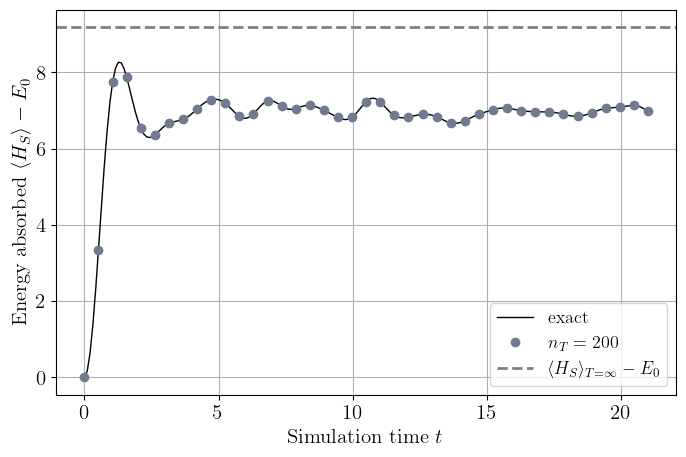

In [12]:
plt.figure(figsize=(8,5))
cmap = plt.cm.bone
colors = cmap(np.linspace(0, 0.5, trotter_step_count))

plt.plot(
    T,
    energy_injected_exact,
    color="black",
    linewidth=1,
    linestyle="-",
    label="exact"
)

plt.plot(
    T_eng,
    injected_energies[:,3],
    'o',
    color = colors[3],
    label=fr"$n_T={int(trotter[3])}$"
    )
# plt.ylim(5.1,10.4)     
plt.xlabel(r"Simulation time $t$")
plt.ylabel(r"Energy absorbed $\langle H_S \rangle-E_0$")
plt.grid()

plt.axhline(
    y=3-E0,
    color="gray",
    linestyle="--",
    linewidth=2,
    label=r"$\langle H_S \rangle_{T=\infty}-E_0$",   # optional, only if you want it in the legend
)

leg = plt.legend(
    loc="lower right",   # <-- top right
    fontsize=13,
    frameon=True
)
plt.savefig("energy_FHM.pdf",bbox_inches = 'tight', dpi =300, format ='pdf')